In [239]:
import pandas as pd
import numpy as np
import ndjson
import regex as re
from datetime import datetime
from datetime import timedelta
import matplotlib.pyplot as plt

In [ ]:
PARTICIPANT_IDS = [
    "naTfYZ3d8COt3WTmTFR9ypgy0Tz2",
    "mLVkGLd7AhU36pB6H6fgVsm9Tr92",
    "dKW8coMFmbXXlLJJuACyOpzV0pJ3",
    "kHq3O8PID3WohPLneFQf5Mgd1PV2",
    "oCHyZruEwYSqCpBF4S4Hu9n5Xzt1",
    "L8wDsmfxnYVc86Cfyr4ZR1ChQN02",
    "t9f6yhqsSFR0d2yG6Ari6mb6Mtl2",
    "58IG0yrKS3azHLbZPlXVx0J4b4k2" "4AjmRha63fPwA1ox4busbgVnqGn2",
    "SJuJ5poZDFSlNGvWP3DpFvCVjre2",
    "FZyXpFmmSoNeKyrC2R03v2st4aP2",
    "oCVzpHGfwYdCvEDyLxbS4MS5Y7Q2",
    "E30TZjLcbiglyj24IcpM2IuqRIF3",
    "tl6zm8SfxLfkvTsdCmqvtG4WIKN2",
    "pDZj1kZEdpXn2RZH1AQXs11pzGt1",
    "JnKvSdG6JUQCGjMN2nrOQLZqnIp1",
    "GEwDFGIKR6Qg0KcMAHz5M7fAlum2",
    "1WmdJoaDFIMQ9r91frt7OLIpEZ03",
]

In [202]:
class User:
    def __init__(self, id):
        self.id = id
        self.data = dict()
        self.action_logs = dict()

    def __str__(self):
        return f"ID: {self.id}, data: {len(self.data)}, action_logs: {len(self.action_logs)}"

In [ ]:
# Load Users
with open("users_backup.ndjson", "r", encoding="utf-8") as f:
    users_raw = ndjson.load(f)

users = dict()
for u in users_raw:
    split_path = u["path"].split("/")
    id = split_path[1]
    if id in PARTICIPANT_IDS:
        if id not in users:
            users[id] = User(id)
        isActionLog = len(split_path) > 2
        if isActionLog:
            action_log_id = split_path[3]
            users[id].action_logs[action_log_id] = u["data"]
        else:
            users[id].data = u["data"]

In [204]:
# Check users loaded correctly
print(len(users))
print(users["1WmdJoaDFIMQ9r91frt7OLIpEZ03"])
print(users["1WmdJoaDFIMQ9r91frt7OLIpEZ03"].data)
print(users["1WmdJoaDFIMQ9r91frt7OLIpEZ03"].action_logs)

16
ID: 1WmdJoaDFIMQ9r91frt7OLIpEZ03, data: 16, action_logs: 233
{'canSeeOutsideGroup': False, 'dateOfBirth': '2001-08-01T00:00:00.000', 'fcmToken': 'fzndCtzAVUZKsy8Q8lNxCo:APA91bGMrNadYmrMNkPL0pg50-cGr_9ZB4Qevqpuk0cz-L2IFdvj2PLjb8OBCw0bA7owSwrbFeTD9F70cRsx7za6T-dknP2flRA8mPy3S8lq6VzAZ_INFAs', 'firstName': 'Zeyu', 'gender': 'Man', 'group': 'C', 'id': '1WmdJoaDFIMQ9r91frt7OLIpEZ03', 'lastName': 'Xia', 'defaultAvailability': {'friday': {'availableTimes': ['8:00', '9:00', '10:00', '14:00', '15:00', '17:00', '16:00', '18:00', '19:00', '20:00'], 'partiallyAvailableTimes': []}, 'monday': {'availableTimes': ['8:00', '9:00', '10:00', '11:00', '12:00', '17:00', '16:00', '18:00', '19:00', '20:00'], 'partiallyAvailableTimes': []}, 'saturday': {'availableTimes': ['9:00', '10:00', '12:00', '8:00', '11:00', '13:00', '14:00', '15:00', '16:00', '17:00', '18:00', '19:00', '20:00'], 'partiallyAvailableTimes': []}, 'sunday': {'availableTimes': ['11:00', '10:00', '9:00', '8:00', '12:00', '13:00', '14:00', 

In [ ]:
class Chat:
    def __init__(self, id):
        self.id = id
        self.data = dict()
        self.messages = dict()
        self.cowalks = dict()

    def __str__(self):
        return f"ID: {self.id}, data: {len(self.data)}, messages: {len(self.messages)}, cowalks = {len(self.cowalks)}"


class Cowalk:
    def __init__(self, id):
        self.id = id
        self.data = dict()
        self.senderWalkDataLogs = dict()
        self.receiverWalkDataLogs = dict()

    def __str__(self):
        return f"ID: {self.id}, data: {len(self.data)}, senderWalkDataLogs: {len(self.senderWalkDataLogs)}, receiverWalkDataLogs: {len(self.receiverWalkDataLogs)}"

In [ ]:
# Load Chats
with open("chats_backup.ndjson", "r", encoding="utf-8") as f:
    chats_raw = ndjson.load(f)

chats = dict()
for c in chats_raw:
    split_path = c["path"].split("/")
    id = split_path[1]
    user1 = id.split("-")[0]
    user2 = id.split("-")[1]
    if user1 in PARTICIPANT_IDS and user2 in PARTICIPANT_IDS:
        if id not in chats:
            chats[id] = Chat(id)
        is_chat = len(split_path) == 2
        is_cowalk_or_message = len(split_path) == 4
        is_data_log = len(split_path) == 6

        if is_chat:
            chats[id].data = c["data"]
        elif is_cowalk_or_message:
            if split_path[2] == "messages":
                message_id = split_path[3]
                chats[id].messages[message_id] = c["data"]
            elif split_path[2] == "cowalks":
                cowalk_id = split_path[3]
                if cowalk_id not in chats[id].cowalks:
                    chats[id].cowalks[cowalk_id] = Cowalk(cowalk_id)
                chats[id].cowalks[cowalk_id].data = c["data"]

        elif is_data_log:
            cowalk_id = split_path[3]
            if cowalk_id not in chats[id].cowalks:
                chats[id].cowalks[cowalk_id] = Cowalk(id)

            data_log_id = split_path[5]
            if split_path[4] == "receiverWalkDataLogs":
                chats[id].cowalks[cowalk_id].receiverWalkDataLogs[data_log_id] = c[
                    "data"
                ]
            elif split_path[4] == "senderWalkDataLogs":
                chats[id].cowalks[cowalk_id].senderWalkDataLogs[data_log_id] = c["data"]

In [ ]:
# Check chats loaded correctly
print(len(chats))
print(chats["FZyXpFmmSoNeKyrC2R03v2st4aP2-1WmdJoaDFIMQ9r91frt7OLIpEZ03"])
print(chats["FZyXpFmmSoNeKyrC2R03v2st4aP2-1WmdJoaDFIMQ9r91frt7OLIpEZ03"].data)
print(chats["FZyXpFmmSoNeKyrC2R03v2st4aP2-1WmdJoaDFIMQ9r91frt7OLIpEZ03"].messages)
print(
    chats["FZyXpFmmSoNeKyrC2R03v2st4aP2-1WmdJoaDFIMQ9r91frt7OLIpEZ03"].cowalks[
        "xepIRtYWne57AeekGPrl"
    ]
)
print(
    chats["FZyXpFmmSoNeKyrC2R03v2st4aP2-1WmdJoaDFIMQ9r91frt7OLIpEZ03"]
    .cowalks["xepIRtYWne57AeekGPrl"]
    .senderWalkDataLogs
)

98
ID: FZyXpFmmSoNeKyrC2R03v2st4aP2-1WmdJoaDFIMQ9r91frt7OLIpEZ03, data: 4, messages: 34, cowalks = 1
{'createdAt': '2026-05-20T13:36:28.637224', 'receiverId': '1WmdJoaDFIMQ9r91frt7OLIpEZ03', 'senderId': 'FZyXpFmmSoNeKyrC2R03v2st4aP2', 'numberCowalksFinishedBothUsers': 2}
{'0V27CL31luHjwuAH0f2g': {'cowalkId': 'xepIRtYWne57AeekGPrl', 'senderId': 'FZyXpFmmSoNeKyrC2R03v2st4aP2', 'text': 'Reza  arrived at the meet-up address (4:33 PM)', 'timeSent': '2026-05-27T16:33:34.772991', 'type': 'walk'}, '4rPX1msVk7Y1lJagrp8O': {'cowalkId': None, 'senderId': 'FZyXpFmmSoNeKyrC2R03v2st4aP2', 'text': 'that’s fine \nwill be waiting you thre ', 'timeSent': '2026-05-27T16:18:18.833036', 'type': 'chat'}, '8XxhatJKSldti5wyr1Vz': {'cowalkId': None, 'senderId': 'FZyXpFmmSoNeKyrC2R03v2st4aP2', 'text': 'that’s ok do you have time now? ', 'timeSent': '2026-05-27T16:16:43.178364', 'type': 'chat'}, 'Bh7aykrNJho2g0UTJb85': {'cowalkId': 'xepIRtYWne57AeekGPrl', 'senderId': '1WmdJoaDFIMQ9r91frt7OLIpEZ03', 'text': 'Zeyu

Questions:

Demographics:

- Gender

Walks overview

- How many walks?
- Average distance traveled of walks
- Average timing of walks
- Average step count of walks

More details

- How many chats before a walk was requested for the first time?
- when chat was viewed, when was first message sent? when was first walk sent?
- viewed profile before chat?

Profile

- how many people have share proximity turned on?
- how many people wrote bios?
- how many people filled out availability?

Messages

- what kind of messages were sent (did they coordinate on the app?)
- did they chat after walking?

After walk survey

- average responses for the survey
- Average familiarity with cowalker on first walk?
- skipped survey?
- Do both walkers' responses line up?
- How long did the after walk survey take


In [260]:
def walk_finished(cowalk):
    receiverId = cowalk.data["receiverId"]
    senderId = cowalk.data["senderId"]
    usersFeedbackSkipped = cowalk.data["usersFeedbackSkipped"]
    usersFeedback = cowalk.data["usersFeedback"]

    receiverFinishedFeedback = (
        usersFeedback[receiverId] or usersFeedbackSkipped[receiverId]
    )

    senderFinishedFeedback = usersFeedback[senderId] or usersFeedbackSkipped[senderId]

    return receiverFinishedFeedback and senderFinishedFeedback

DURATION OF WALKS (H:MM:SS) 
Mean: 0:23:46.119225 
SD: 0:22:59.881139 
Median: 0:15:15.986381 
Max: 1:59:49.614774 
Min: 0:00:06.564391


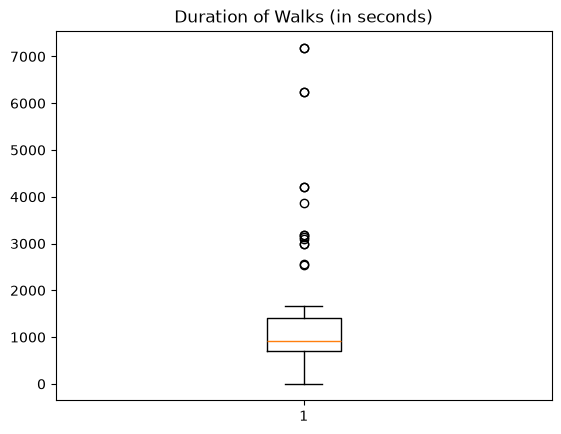

In [ ]:
# How long were walks?
all_time_durations = []
for chat in chats.values():
    cowalks = chat.cowalks
    for cw in cowalks.values():
        receiverId = cw.data["receiverId"]
        senderId = cw.data["senderId"]
        usersStartTime = cw.data["usersStartTime"]
        usersFinishTime = cw.data["usersFinishTime"]
        if walk_finished(cw):
            receiverTimeElapsed = datetime.fromisoformat(
                usersFinishTime[receiverId]
            ) - datetime.fromisoformat(usersStartTime[receiverId])

            senderTimeElapsed = datetime.fromisoformat(
                usersFinishTime[senderId]
            ) - datetime.fromisoformat(usersStartTime[senderId])

            all_time_durations.append(receiverTimeElapsed.total_seconds())
            all_time_durations.append(senderTimeElapsed.total_seconds())

mean = np.mean(all_time_durations)
sd = np.std(all_time_durations)
median = np.median(all_time_durations)
min = np.min(all_time_durations)
max = np.max(all_time_durations)

print(
    "DURATION OF WALKS (H:MM:SS)",
    "\nMean:",
    str(timedelta(seconds=mean)),
    "\nSD:",
    str(timedelta(seconds=sd)),
    "\nMedian:",
    str(timedelta(seconds=median)),
    "\nMax:",
    str(timedelta(seconds=max)),
    "\nMin:",
    str(timedelta(seconds=min)),
)

plt.boxplot(all_time_durations)
plt.title("Duration of Walks (in seconds)")
plt.show()

24 HOUR TIME OF WALKS (HH:MM:SS) 
Mean: 15:48:15 
SD: 3:09:20.348806 
Median: 16:25:00 
Max: 22:57:00 
Min: 9:03:00


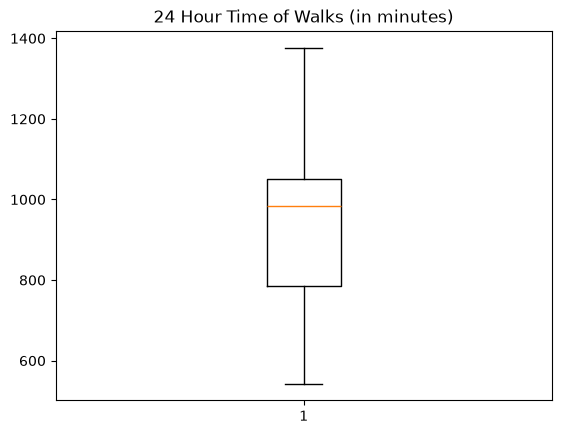

In [267]:
# When were walks happening?

all_walks_24_hour_time_as_minutes = []
for chat in chats.values():
    cowalks = chat.cowalks
    for cw in cowalks.values():
        receiverId = cw.data["receiverId"]
        senderId = cw.data["senderId"]
        usersStartTime = cw.data["usersStartTime"]
        if walk_finished(cw):
            receiverStartTime = datetime.fromisoformat(usersStartTime[receiverId])
            receiverStart24HourTimeAsMinutes = receiverStartTime.hour * 60 + receiverStartTime.minute
            senderStartTime = datetime.fromisoformat(usersStartTime[senderId])
            senderStart24HourTimeAsMinutes = senderStartTime.hour * 60 + senderStartTime.minute

            all_walks_24_hour_time_as_minutes.append(receiverStart24HourTimeAsMinutes)
            all_walks_24_hour_time_as_minutes.append(senderStart24HourTimeAsMinutes)


mean = np.mean(all_walks_24_hour_time_as_minutes)
sd = np.std(all_walks_24_hour_time_as_minutes)
median = np.median(all_walks_24_hour_time_as_minutes)
min = np.min(all_walks_24_hour_time_as_minutes)
max = np.max(all_walks_24_hour_time_as_minutes)

print(
    "24 HOUR TIME OF WALKS (HH:MM:SS)",
    "\nMean:",
    str(timedelta(minutes=mean)),
    "\nSD:",
    str(timedelta(minutes=sd)),
    "\nMedian:",
    str(timedelta(minutes=median)),
    "\nMax:",
    str(timedelta(minutes=float(max))),
    "\nMin:",
    str(timedelta(minutes=float(min))),
)

plt.boxplot(all_walks_24_hour_time_as_minutes)
plt.title("24 Hour Time of Walks (in minutes)")
plt.show()